#Modelo de Machine Learning empleando la librería FLAML para la predicción del desempeño del alumnado en función a los hábitos, aspectos socioeconómicos, y académicos

El propósito es analizar el desempeño de 250,000 estudiantes para ver que en función de las características (Motivación, Horas de Estudio Diarias, Horas de Sueño, Nivel de Estrés, Tasa de Asistencia, si tiene tutoría privada, Ingreso Familiar, Nivel Educativo de los Padres, Calidad de Internet) debido a que estas tienen una correlación que componen la tasa desempeño aprobatorio y reprobatorio cuales facilitan el entrenamiento de un modelo para poder predecir resagos y poder prevenir no acreditar las unidades de aprendisaje asignadas.

#Manejo y limpieza del data frame de "Student Data"

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv('student_data.csv') #cargamos el data frame de los estudiantes
df.head(2) #mostramos el head con las dos primeras entradas del data frame

,gender,age,parental_education_level,family_income,daily_study_hours,attendance_rate,sleep_hours,stress_level,motivation_score,private_tutoring,internet_quality,math_score,reading_score,writing_score,pass_fail
0,Female,15,2,45000.0,2.9,0.916,8.3,6.0,16,False,2,21,29,29,Fail
1,Male,19,2,15000.0,2.8,0.760,6.8,5.0,58,False,3,56,37,45,Fail


Manejo de valores faltantes

In [6]:
print("\033[1;34mValores faltantes:\033[0m")
print (df.isnull().sum()) #mostramos los valores faltantes dentro del data frame para manejar los valores faltantes

Valores faltantes:
gender                         0
age                            0
parental_education_level       0
family_income               4025
daily_study_hours              0
attendance_rate                0
sleep_hours                 4113
stress_level                3913
motivation_score               0
private_tutoring               0
internet_quality               0
math_score                     0
reading_score                  0
writing_score                  0
pass_fail                      0
dtype: int64


In [7]:
# Tanto como family_income, sleep_hours, stress_level tienen valores faltantes, por lo que vamos a colocar valores según sea la mediana o media

from sklearn.impute import SimpleImputer

imputer_mean = SimpleImputer(strategy='mean')  # Puede ser "mean", "median", "most_frequent"
imputer_median = SimpleImputer(strategy='median')

df[['sleep_hours']] = imputer_mean.fit_transform(df[['sleep_hours']])
df[['family_income']] = imputer_median.fit_transform(df[['family_income']])
df[['stress_level']] = imputer_median.fit_transform(df[['stress_level']])

Codificación de variables categóricas

In [8]:
#Debido como hay variables categóricas, como en gender, private tutoring y pass / fail vamos a utilizar el OneHotEncoder para emplear estas variables

from sklearn.preprocessing import OneHotEncoder

categorical_columns = ['gender', 'private_tutoring', 'pass_fail']

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoded_features = encoder.fit_transform(df[categorical_columns])
encoded_df_subset = pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(categorical_columns), index=df.index)
df = df.drop(columns = categorical_columns)
df = pd.concat([df, encoded_df_subset], axis=1)

df.head(2)

,age,parental_education_level,family_income,daily_study_hours,attendance_rate,sleep_hours,stress_level,motivation_score,internet_quality,math_score,reading_score,writing_score,gender_Female,gender_Male,private_tutoring_False,private_tutoring_True,pass_fail_Fail,pass_fail_Pass
0,15,2,45000.0,2.9,0.916,8.3,6.0,16,2,21,29,29,1.0,0.0,1.0,0.0,1.0,0.0
1,19,2,15000.0,2.8,0.760,6.8,5.0,58,3,56,37,45,0.0,1.0,1.0,0.0,1.0,0.0


Estandarización de la base de datos

In [9]:
#Para  para poner todas las variables numéricas en la misma escala, evitando que unas dominen sobre otras
#y mejorando el rendimiento de los algoritmos de machine learning en clasificación

from numpy import asarray
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled = scaler.fit_transform(df)
standar_df = pd.DataFrame(scaled, columns = df.columns)

standar_df.head(2)

,age,parental_education_level,family_income,daily_study_hours,attendance_rate,sleep_hours,stress_level,motivation_score,internet_quality,math_score,reading_score,writing_score,gender_Female,gender_Male,private_tutoring_False,private_tutoring_True,pass_fail_Fail,pass_fail_Pass
0,-1.910690,-1.050098,-0.173903,-1.024725,0.367330,0.644120,0.626743,-2.388873,-1.26322,-2.458722,-1.857838,-1.866949,0.960047,-0.960047,0.614059,-0.614059,1.098744,-1.098744
1,0.515152,-1.050098,-1.013245,-1.144921,-2.249586,-0.984638,-0.065994,0.690913,0.12060,-0.408172,-1.414287,-0.933396,-1.041615,1.041615,0.614059,-0.614059,1.098744,-1.098744


Mapa de calor para observar correlación entre variables

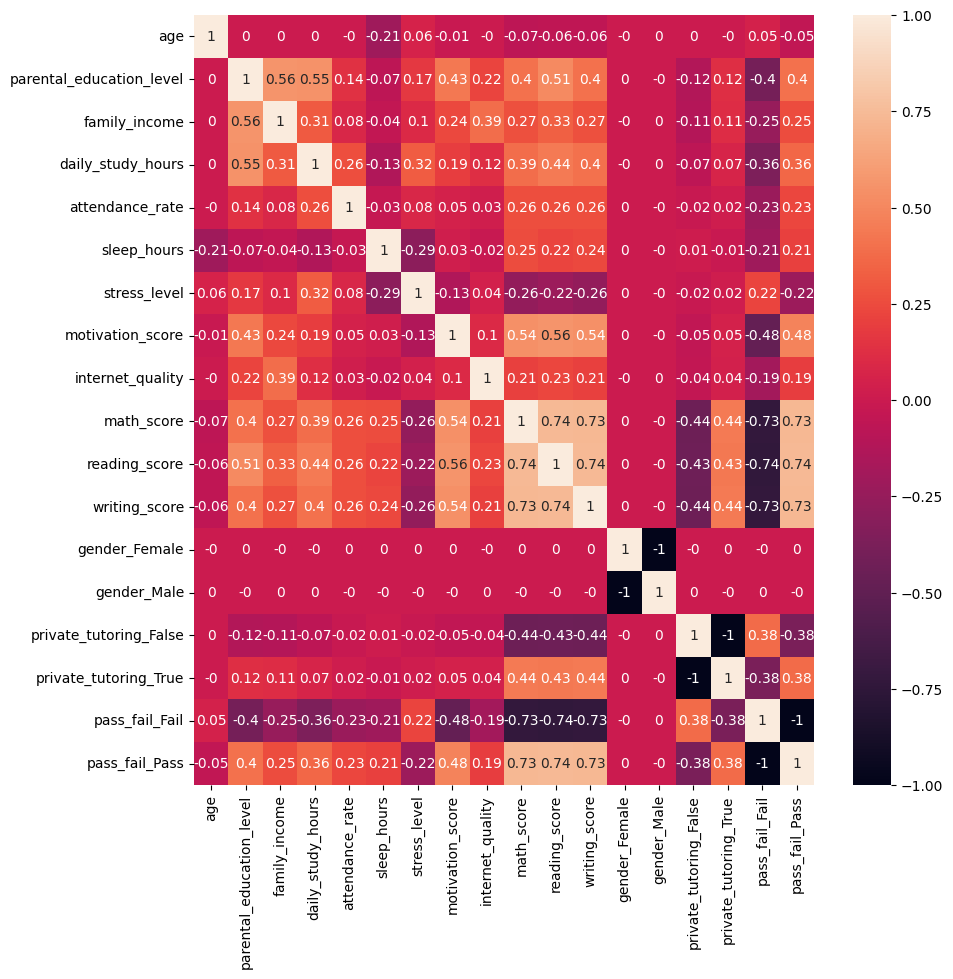

In [10]:
#Para observar las variables más correlacionadas entre sí las observamos dentro de un heatmap

plt.figure(figsize=(10, 10))
matrizCorrelación = df.corr().round(2)
sns.heatmap(data=matrizCorrelación,annot=True);

###Correlaciones destacadas:

- Los puntajes académicos (math, reading, writing) entre sí mismas haciendo que si tenían buenos puntajes en una probablmente las tenían en todas

- Pass / Fall de los años respecto a las materias (math, reading, writing) además de tenere relación con la motivación de cada estudiante.

- Si había tutor privado se relacionaba a mejor desempeño en las materias.

- Entre mejor motivación tenían mejores calificaciones

- Otros factores son la educación parental que se relaciona con los buenos ingresos de la familia así como las horas de estudio de los estudiantes.

#Aplicación de la libreria FLAML y entrenamiento del modelo de ML

In [34]:
Y = df['pass_fail_Pass'] #Variable objetivo o la que quiero predecir, si aprobó o no aprobó

X = df[[ # Variables de entrada. Son las variables que usas para predecir la variable objetivo.
    'motivation_score',
    'daily_study_hours',
    'attendance_rate',
    'family_income',
    'parental_education_level',
    'internet_quality',
    'sleep_hours',
    'stress_level',
    'private_tutoring_True'
]]

#La X incluye todas las variables que tenían más correlación con la variable de la tasa de aprobación
#Las variables más correolacionadas de entrada pertenecen a factores académicos, personales y socioeconómicos del estudiante que pueden influir en su desempeño.

In [12]:
!pip install flaml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 337.7/337.7 kB 10.7 MB/s eta 0:00:00


In [35]:
#aplicamos el FLAML con el AutoML para saber qué modelo de ML es el mejor o responde mejor a las predicciones posibles
#En este caso dejamos 2 minutos para que probara entre los modelos de LGBM, xgboost, random forest, extra tree, k-neighbor y es support vector machine

from flaml import AutoML
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

automl = AutoML()

automl.fit(
    X_train,
    Y_train,
    task="classification", #quiero predecir si Pass / Fail
    metric='accuracy', # en función a su accuracy
    time_budget=120, # segundos en probar hiperparámetros y modelos de clasificación
    estimator_list=[
        "lgbm",           #LightGBM (Light Gradient Boosting Machine)
        "xgboost",        #Extreme Gradient Boosting (XGBoost)
        "rf",             #	Random Forest
        "extra_tree",     #Extra Trees (Extremely Randomized Trees)
        "kneighbor",      # KNeighborsClassifier
        'svc'             # Support Vector Machine
    ]
)


#Se pueden aplicar:

#only ['xgboost', 'xgb_limitdepth', 'rf', 'lgbm', 'lgbm_spark', 'rf_spark', 'lrl1', 'lrl2', 'catboost',
#'extra_tree', 'kneighbor', 'transformer', 'transformer_ms', 'histgb', 'svc', 'sgd', 'nb_spark', 'enet', 'lassolars', 'glr_spark', 'lr_spark',
#'svc_spark', 'gbt_spark', 'aft_spark'] are supported

[flaml.automl.logger: 04-05 19:30:39] {2375} INFO - task = classification
[flaml.automl.logger: 04-05 19:30:39] {2386} INFO - Evaluation method: holdout
[flaml.automl.logger: 04-05 19:30:39] {2489} INFO - Minimizing error metric: 1-accuracy
[flaml.automl.logger: 04-05 19:30:39] {2606} INFO - List of ML learners in AutoML Run: ['lgbm', 'xgboost', 'rf', 'extra_tree', 'kneighbor', 'svc']
[flaml.automl.logger: 04-05 19:30:39] {2911} INFO - iteration 0, current learner lgbm
[flaml.automl.logger: 04-05 19:30:39] {3046} INFO - Estimated sufficient time budget=5149s. Estimated necessary time budget=19s.
[flaml.automl.logger: 04-05 19:30:39] {3097} INFO -  at 0.5s,	estimator lgbm's best error=2.1119e-01,	best estimator lgbm's best error=2.1119e-01
[flaml.automl.logger: 04-05 19:30:39] {2911} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 04-05 19:30:39] {3097} INFO -  at 0.5s,	estimator lgbm's best error=2.1119e-01,	best estimator lgbm's best error=2.1119e-01
[flaml.automl.logge

INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune


[flaml.automl.logger: 04-05 19:30:39] {3097} INFO -  at 0.6s,	estimator svc's best error=2.5769e-01,	best estimator lgbm's best error=1.9806e-01
[flaml.automl.logger: 04-05 19:30:39] {2911} INFO - iteration 4, current learner lgbm
[flaml.automl.logger: 04-05 19:30:39] {3097} INFO -  at 0.7s,	estimator lgbm's best error=1.3444e-01,	best estimator lgbm's best error=1.3444e-01
[flaml.automl.logger: 04-05 19:30:39] {2911} INFO - iteration 5, current learner lgbm
[flaml.automl.logger: 04-05 19:30:39] {3097} INFO -  at 0.7s,	estimator lgbm's best error=1.3444e-01,	best estimator lgbm's best error=1.3444e-01
[flaml.automl.logger: 04-05 19:30:39] {2911} INFO - iteration 6, current learner lgbm
[flaml.automl.logger: 04-05 19:30:39] {3097} INFO -  at 0.8s,	estimator lgbm's best error=1.2294e-01,	best estimator lgbm's best error=1.2294e-01
[flaml.automl.logger: 04-05 19:30:39] {2911} INFO - iteration 7, current learner lgbm
[flaml.automl.logger: 04-05 19:30:39] {3097} INFO -  at 0.8s,	estimator l

In [36]:
print("Mejor modelo:", automl.model.estimator) #el mejor modelo es XGBClassifier que es un clasificador de XGBoost

Mejor modelo: XGBClassifier(base_score=None, booster=None, callbacks=[],
              colsample_bylevel=np.float64(0.4579673515373888),
              colsample_bynode=None,
              colsample_bytree=np.float64(0.6622373597643373), device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=None, grow_policy='lossguide', importance_type=None,
              interaction_constraints=None,
              learning_rate=np.float64(0.1753742951355398), max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=0, max_leaves=29,
              min_child_weight=np.float64(5.205698698321171), missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=333,
              n_jobs=-1, num_parallel_tree=None, ...)


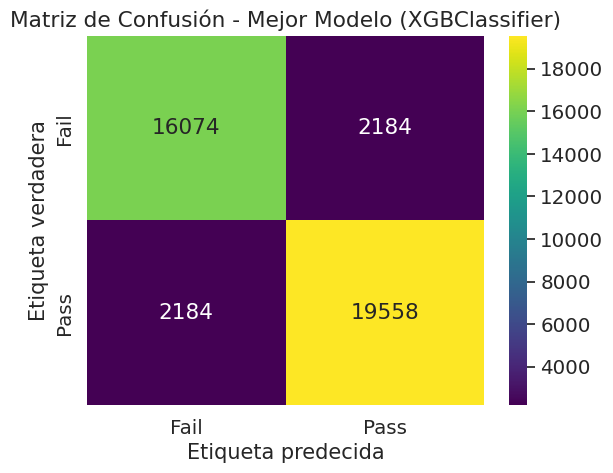

In [37]:
from sklearn import metrics
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

#Calculamos la matriz de confusión para ver el sesgo dentro de nuestro modelo

# Obtener las predicciones del mejor modelo
y_pred_confusion = automl.predict(X_test)

# Calcular la matriz de confusión
confusion_matrix = metrics.confusion_matrix(Y_test, y_pred_confusion)

# Definir los nombres de las clases (basado en 'pass_fail_Pass' siendo 0 o 1)
target_names = ['Fail', 'Pass']

matrix_df = pd.DataFrame(confusion_matrix, index=target_names, columns=target_names)
ax = plt.axes()
sns.set(font_scale=1.3)

sns.heatmap(matrix_df, annot=True, fmt="g", ax=ax, cmap="viridis")
ax.set_title(f'Matriz de Confusión - Mejor Modelo ({automl.model.estimator.__class__.__name__})')
ax.set_xlabel("Etiqueta predecida", fontsize=15)
ax.set_ylabel("Etiqueta verdadera", fontsize=15)

plt.show()

In [38]:
from sklearn.metrics import accuracy_score

#Con las métricas de sklearn podemos definir qué tan bueno o malo fue el modelo dado por FLAML (los detalles se incluyen en el archivo de información)

y_pred = automl.predict(X_test)
print("\033[1;34mAccuracy:\033[0m", accuracy_score(Y_test, y_pred)) #Métrica empleada con la libreria de flaml en AutoML
print("Precision:", metrics.precision_score(Y_test, y_pred))
print("Recall:", metrics.recall_score(Y_test, y_pred))
print("Specificity:", metrics.recall_score(Y_test, y_pred, pos_label=0))
print("F1 Score:", metrics.f1_score(Y_test, y_pred))

Accuracy: 0.8908
Precision: 0.8995492594977463
Recall: 0.8995492594977463
Specificity: 0.8803812027604337
F1 Score: 0.8995492594977463


#Guardar el modelo hecho

In [52]:
# Guardar el modelo
import pickle
with open ('student_model.pkl', 'wb') as f:
  pickle.dump (automl.model.estimator, f)

#Creación de una interfaz con Streamlit

In [1]:
!pip -q install --upgrade streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 71.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 97.5 MB/s eta 0:00:00


In [2]:
#Cerrar el tunnel de conexión

!pkill -f streamlit || true
!pkill -f cloudflared || true
print("Procesos detenidos.")

^C
^C
Procesos detenidos.


In [88]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

st.set_page_config (
  page_title = 'Predicción escolar',
  page_icon="🧠",
  layout = 'wide',
  initial_sidebar_state = 'expanded'
)

@st.cache_data
def load_and_preprocess_data():
    df = pd.read_csv('student_data.csv')

    imputer_mean = SimpleImputer(strategy='mean')
    imputer_median = SimpleImputer(strategy='median')

    df.loc[:, 'sleep_hours'] = imputer_mean.fit_transform(df[['sleep_hours']])
    df.loc[:, 'family_income'] = imputer_median.fit_transform(df[['family_income']])
    df.loc[:, 'stress_level'] = imputer_median.fit_transform(df[['stress_level']])

    # One-hot encode categorical variables
    categorical_columns = ['gender', 'private_tutoring', 'pass_fail']
    encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    encoded_features = encoder.fit_transform(df[categorical_columns])
    encoded_df_subset = pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(categorical_columns), index=df.index)
    df = df.drop(columns=categorical_columns)
    df = pd.concat([df, encoded_df_subset], axis=1)

    return df

# carga del data frame procesado
processed_df = load_and_preprocess_data()

#st.cache_resource.clear() #solo si se quiere actualizar el modelo

@st.cache_resource
def load_model():
    return joblib.load("student_model.pkl")

model = load_model()

# Menú dentro de la app
st.sidebar.title("Menú")
opcion = st.sidebar.radio(
    "Ir a:",
    ["Análisis exploratorio", "Predicción"]
)

# Contenido según la opción
if opcion == "Análisis exploratorio":
    st.title("👀👌 Análisis de la base de datos de los estudiantes")
    st.write("Obten la base de datos en: https://www.kaggle.com/datasets/riteshswami08/student-academic-performance-and-behavioral-factor")
    st.dataframe(processed_df.head(4))

    ####################################

    # Calcular promedio correctamente
    calificaciones_promedio = (
        processed_df['math_score'] +
        processed_df['reading_score'] +
        processed_df['writing_score']
    ) / 3

    fig, ax = plt.subplots(figsize=(10,5))
    ax.hist(calificaciones_promedio, bins=10, edgecolor='black', alpha=0.7)
    media = np.mean(calificaciones_promedio)
    ax.axvline(media, color='red', linestyle='dashed', linewidth=2, label=f'Media: {media:.2f}')
    ax.set_xlabel('Rango de Calificaciones')
    ax.set_ylabel('Número de Estudiantes')
    ax.set_title('Distribución de Calificaciones')
    ax.legend()
    st.pyplot(fig)

    st.markdown("### 📊 Distribución de calificaciones")
    st.write(
        "En esta gráfica se observa la distribución del promedio de calificaciones de los estudiantes. "
        "La forma se aproxima a una campana de Gauss, lo que indica que la mayoría se concentra alrededor de un valor central. "
        "En este caso, la media es aproximadamente 62.16, lo que sugiere que muchos estudiantes logran aprobar con una calificación cercana al mínimo requerido."
    )

    st.write(
        "Además, se observa que existen menos casos en los extremos: pocos estudiantes obtienen calificaciones muy bajas o muy altas. "
        "Esto refleja una distribución equilibrada con concentración en niveles de aprobación básica dentro de la base de datos analizada."
    )

    #########################################

    fig, ax = plt.subplots(figsize=(6,4))

    con = processed_df[processed_df['private_tutoring_True'] == 1]['math_score']
    sin = processed_df[processed_df['private_tutoring_True'] == 0]['math_score']

    ax.bar(['Con tutoría', 'Sin tutoría'], [con.mean(), sin.mean()], color=['green', 'yellow'])
    ax.set_title("Impacto de tutoría en matemáticas")

    st.pyplot(fig)

    st.markdown("### 📈 Impacto de la tutoría")
    st.write(
        "Esta gráfica muestra el efecto de la tutoría privada en el rendimiento académico. "
        "Se observa que los estudiantes que reciben tutoría presentan, en promedio, calificaciones más altas que aquellos que no la reciben."
    )

    st.write(
        "En particular, los estudiantes con tutoría tienden a ubicarse en rangos cercanos a 70–80, "
        "mientras que los que no cuentan con este apoyo suelen estar entre 50 y 60. "
        "Esto sugiere que la tutoría tiene un impacto positivo en el desempeño académico."
    )

    #########################################

    fig, ax = plt.subplots(figsize=(6,4))

    calificaciones_promedio = (
        processed_df['math_score'] +
        processed_df['reading_score'] +
        processed_df['writing_score']
    ) / 3

    ax.set_title("Desempeño académico en contraste al nivel de estrés")
    ax.scatter(processed_df['stress_level'], calificaciones_promedio, c=processed_df['stress_level'], cmap='viridis', alpha=0.5)

    ax.set_xlabel("Estrés")
    ax.set_ylabel("Promedio académico")

    st.pyplot(fig)

    st.markdown("### 📉 Desempeño académico vs nivel de estrés")
    st.write(
        "En esta gráfica se analiza la relación entre el nivel de estrés y el promedio académico. "
        "Se observa que niveles bajos de estrés están asociados con una mayor probabilidad de obtener calificaciones altas."
    )

    st.write(
        "A medida que el estrés aumenta, las calificaciones se vuelven más dispersas. "
        "En niveles intermedios el rendimiento es más variable, y en niveles altos se observa tanto presencia de calificaciones altas como bajas, "
        "aunque con mayor dificultad para alcanzar resultados sobresalientes de forma consistente."
    )

    #########################################


elif opcion == "Predicción":
    st.title("👨‍🏫 Prediccion sobre el estado de desempeño del alumnado")

    st.subheader ('Características Personales / hábitos 👩‍💻🤟🏼')
    motivation_score = st.slider ('Puntaje de Motivación', 10, 100, 55)
    daily_study_hours = st.slider ('Horas de Estudio Diarias', 0.0, 10.0, 5.0, step=0.1)
    sleep_hours = st.slider ('Horas de Sueño', 4.0, 11.0, 7.5, step=0.1)
    stress_level = st.slider ('Nivel de Estrés', 1.0, 10.0, 5.5, step=0.1)

    st.subheader ('Características Contexto educativo 🏫⏰')
    attendance_rate = st.slider ('Tasa de Asistencia', 0.0, 1.0, 0.5, step=0.01)
    private_tutoring = st.radio('¿Recibe tutoría privada?', ('Sí', 'No'))
    private_tutoring_True = 1.0 if private_tutoring == 'Sí' else 0.0

    st.subheader ('Características Socioeconómicas 💸👨‍👩‍👦‍👦')
    family_income = st.slider ('Ingreso Familiar', 0, 2500000, 1250000)
    parental_education_level = st.slider ('Nivel Educativo de los Padres', 1, 7, 4)
    internet_quality = st.slider ('Calidad de Internet', 1, 5, 3)

    input_data = {
        'motivation_score': motivation_score,
        'daily_study_hours': daily_study_hours,
        'attendance_rate': attendance_rate,
        'family_income': family_income,
        'parental_education_level': parental_education_level,
        'internet_quality': internet_quality,
        'sleep_hours': sleep_hours,
        'stress_level': stress_level,
        'private_tutoring_True': private_tutoring_True
    }

    feature_columns = [
        'motivation_score',
        'daily_study_hours',
        'attendance_rate',
        'family_income',
        'parental_education_level',
        'internet_quality',
        'sleep_hours',
        'stress_level',
        'private_tutoring_True'
    ]

    input_df = pd.DataFrame([input_data], columns=feature_columns)

    # Mostrar las características de entrada
    st.subheader ('Características de entrada')
    st.write (input_df)

    # Hace la predicción
    if st.button('Predecir'):
        prediction = model.predict(input_df)
        prediction_proba = model.predict_proba(input_df)

        st.subheader ('Resultado de Predicción')
        if prediction[0] == 1: # Asumiendo que 1 is 'Pasar' and 0 is 'reprobar'
            st.success(f'El estudiante **aprobará** con una probabilidad de {prediction_proba[0][1]*100:.2f}% 👨🏻‍🎓')
        else:
            st.error(f'El estudiante **no aprobará** con una probabilidad de {prediction_proba[0][0]*100:.2f}% 🤷🏼')

        st.markdown("---")
        st.write("Interpretación:")
        st.info("Un resultado 'Aprobará' indica una alta probabilidad de éxito académico, mientras que 'No aprobará' sugiere que el estudiante podría enfrentar dificultades y podría necesitar apoyo adicional.")

Overwriting app.py


In [19]:
!pkill -f streamlit || true
!nohup streamlit run app.py --server.port 8501 --server.address 0.0.0.0 > streamlit.log 2>&1 &

import time
time.sleep(6)

print("Primeras líneas del log de Streamlit:")
!head -n 20 streamlit.log

^C
Primeras líneas del log de Streamlit:




In [20]:

!pkill -f cloudflared || true
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared
!chmod +x cloudflared
!nohup ./cloudflared tunnel --url http://localhost:8501 > cloudflared.log 2>&1 &

import time, re
url = None

for _ in range(30):
    time.sleep(2)
    with open("cloudflared.log", "r", encoding="utf-8", errors="ignore") as f:
        log = f.read()
    m = re.search(r'https://[-a-z0-9]+\.trycloudflare\.com', log)
    if m:
        url = m.group(0)
        break

if url:
    print("Abre esta URL en otra pestaña:")
    print(url)
else:
    print("No se pudo extraer la URL todavía. Ejecuta la siguiente celda para revisar logs.")

^C
Abre esta URL en otra pestaña:
https://adequate-fares-acceptance-tribute.trycloudflare.com


In [21]:
print("=== STREAMLIT LOG ===")
!tail -n 50 streamlit.log

print("\n=== CLOUDFLARED LOG ===")
!tail -n 50 cloudflared.log

=== STREAMLIT LOG ===



  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.186.9.255:8501


=== CLOUDFLARED LOG ===
2026-04-05T19:10:19Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-04-05T19:10:19Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-04-05T19:10:23Z INF +-------------------------------------------------------------------------